# Milestone 1 - Zrozumienie zbioru danych (MAPB)

Notebook realizuje wymagania Milestone 1:
- opis zbioru i kontekstu,
- identyfikacja kluczowych atrybutow logu zdarzen,
- analiza jakosci danych,
- eksploracyjna analiza danych,
- statystyki podstawowe oraz wizualizacje.

In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid') # Ustawienie matplotlib na seaborn z gridami

In [ ]:

candidate_dirs = [
    Path('.'),  # bieżący katalog
    Path('Dataset_8087219'),  # subfolder
    Path('..') / 'Dataset_8087219',  # katalog nadrzędny
]

# Szukamy folderu, w którym znajduje się plik Signature_Burn.txt
DATA_DIR = None
for d in candidate_dirs:
    if (d / 'Signature_Burn.txt').exists():
        DATA_DIR = d.resolve()  # resolve() zwraca ścieżkę absolutną
        break

# Jeśli folder nie został znaleziony, wyrzuć błąd
if DATA_DIR is None:
    raise FileNotFoundError(
        'Nie znaleziono folderu z plikami Signature_*.txt. '
        'Uruchom notebook z katalogu projektu albo popraw sciezke DATA_DIR.'
    )


# Zbieramy wszystkie pliki Signature_*.txt i sortujemy alfabetycznie
signature_files = sorted(DATA_DIR.glob('Signature_*.txt'))
print(f'DATA_DIR: {DATA_DIR}')
print(f'Liczba plikow sygnatur: {len(signature_files)}')
# Wyświetl listę znalezionych plików (dla nas)
signature_files

DATA_DIR: D:\!Magisterka\SEMESTR_8\MODELOWANIE_I_ANALIZA_PROCESOW_BIZNESOWYCH\Dataset_8087219
Liczba plikow sygnatur: 6


[WindowsPath('D:/!Magisterka/SEMESTR_8/MODELOWANIE_I_ANALIZA_PROCESOW_BIZNESOWYCH/Dataset_8087219/Signature_Burn.txt'),
 WindowsPath('D:/!Magisterka/SEMESTR_8/MODELOWANIE_I_ANALIZA_PROCESOW_BIZNESOWYCH/Dataset_8087219/Signature_Mill.txt'),
 WindowsPath('D:/!Magisterka/SEMESTR_8/MODELOWANIE_I_ANALIZA_PROCESOW_BIZNESOWYCH/Dataset_8087219/Signature_Pickup-move-oven.txt'),
 WindowsPath('D:/!Magisterka/SEMESTR_8/MODELOWANIE_I_ANALIZA_PROCESOW_BIZNESOWYCH/Dataset_8087219/Signature_Sort.txt'),
 WindowsPath('D:/!Magisterka/SEMESTR_8/MODELOWANIE_I_ANALIZA_PROCESOW_BIZNESOWYCH/Dataset_8087219/Signature_Storage.txt'),
 WindowsPath('D:/!Magisterka/SEMESTR_8/MODELOWANIE_I_ANALIZA_PROCESOW_BIZNESOWYCH/Dataset_8087219/Signature_Transport.txt')]

In [ ]:
if not signature_files:
    raise ValueError('Lista signature_files jest pusta - nie ma czego analizowac.')

records = []  # Lista do zbierania wszystkich rekordów z wszystkich plików

for file_path in signature_files:
    # Odtwarzamy nazwę aktywności z nazwy pliku (np. "Burn" z "Signature_Burn.txt")
    activity = file_path.stem.replace('Signature_', '')
    # Tworzymy identyfikator przypadku (case_id) BO W SUROWYCH DANYCH GO NIE MA!
    case_id = f'case_{activity}_001'

    # Otwieramy plik i czytamy linia po linii
    with file_path.open('r', encoding='utf-8') as f:
        for idx, line in enumerate(f, start=1):
            line = line.strip()  # Usuwamy znaki spacji na początku/końcu
            if not line:
                continue  # Pomijamy puste linie

            # Parsujemy JSON do słownika
            obj = json.loads(line)
            # Tworzymy rekord z podstawowymi atrybutami 
            row = {
                'case_id': case_id,  # ID przypadku
                'activity': activity,  # Nazwa aktywności procesu
                'event_index': idx,  # Numer zdarzenia w sekwencji
                'station': obj.get('station'),  # Nazwa stacji/maszyny
                'timestamp_raw': obj.get('timestamp')  # Czas zdarzenia (surowy format)
            }

            # Rozpakowujemy pola "events" (sygnały czujników/aktuatorów)
            event_payload = obj.get('events', {})
            for key, value in event_payload.items():
                row[key] = value  # Dodajemy każdy sygnał do rekordu

            records.append(row)

df = pd.DataFrame(records)  # Zamieniamy listę rekordów na tabelę
if df.empty:
    raise ValueError('Wczytano 0 rekordow - sprawdz format plikow Signature_*.txt.')

# Konwertujemy surowy timestamp na date + czas
df['timestamp'] = pd.to_datetime(df['timestamp_raw'], utc=True, errors='coerce')

# Zapisujemy całą tabelę do pliku CSV (dla możliwości przejrzenia całości)
df.to_csv("df_full.csv", index=False, encoding="utf-8-sig")

df

,case_id,activity,event_index,station,timestamp_raw,i1_pos_switch,i2_pos_switch,i5_light_barrier,m1_speed,o7_valve,o8_compressor,i3_pos_switch,i4_light_barrier,m2_speed,m3_speed,i7_light_barrier,o7_compressor,o8_valve,i1_light_barrier,i3_light_barrier,i6_light_barrier,i8_light_barrier,o5_valve,o6_valve,i2_light_barrier,i5_pos_switch,i6_pos_switch,i7_pos_switch,i8_pos_switch,m4_speed,i4_pos_switch,timestamp
0,case_Burn_001,Burn,1,OV_1,2023-03-20T10:11:01Z,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-20 10:11:01+00:00
1,case_Burn_001,Burn,2,OV_1,2023-03-20T10:11:03Z,0.0,0.0,1.0,-512.0,512.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-20 10:11:03+00:00
2,case_Burn_001,Burn,3,OV_1,2023-03-20T10:11:05Z,1.0,0.0,1.0,0.0,512.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-20 10:11:05+00:00
3,case_Burn_001,Burn,4,OV_1,2023-03-20T10:11:07Z,1.0,0.0,1.0,0.0,512.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-20 10:11:07+00:00
4,case_Burn_001,Burn,5,OV_1,2023-03-20T10:11:09Z,1.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-20 10:11:09+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,case_Transport_001,Transport,13,WT_1,2023-03-20T10:57:31Z,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,512.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,512.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2023-03-20 10:57:31+00:00
115,case_Transport_001,Transport,14,WT_1,2023-03-20T10:57:33Z,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,512.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,512.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2023-03-20 10:57:33+00:00
116,case_Transport_001,Transport,15,WT_1,2023-03-20T10:57:35Z,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,512.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,512.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2023-03-20 10:57:35+00:00
117,case_Transport_001,Transport,16,WT_1,2023-03-20T10:57:37Z,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,512.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,512.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2023-03-20 10:57:37+00:00


## Kontekst zbioru

W tym workspace dostepny jest podzbior sygnatur procesowych (pliki `Signature_*.txt`)
oraz gotowe aplikacje CEP (Siddhi) do wykrywania aktywnosci:
Burn, Mill, Pickup-move-oven, Sort, Storage, Transport.

Kazdy plik sygnatury zawiera sekwencje zdarzen czasowych JSON ze stacji produkcyjnej
(np. OV_1, MM_1, WT_1, HBW_1) i wektorami sygnalow czujnikow/aktuatorow.

In [ ]:
num_events = len(df)  # Całkowita liczba zdarzeń
num_cases = df['case_id'].nunique()  # Liczba unikalnych przypadków
num_activities = df['activity'].nunique()  # Liczba unikalnych aktywności
num_stations = df['station'].nunique()  # Liczba unikalnych stacji


summary = pd.DataFrame({
    'metric': ['events', 'cases', 'activities', 'stations'],
    'value': [num_events, num_cases, num_activities, num_stations]
})
summary

,metric,value
0,events,119
1,cases,6
2,activities,6
3,stations,6


In [ ]:

events_per_activity = df.groupby('activity', as_index=False).size().rename(columns={'size': 'events'})
events_per_case = df.groupby('case_id', as_index=False).size().rename(columns={'size': 'events'})


events_per_activity

,activity,events
0,Burn,13
1,Mill,12
2,Pickup-move-oven,18
3,Sort,12
4,Storage,47
5,Transport,17


## Kluczowe atrybuty logu zdarzen

Sprawdzamy typowe atrybuty process mining:
- case id,
- activity,
- timestamp,
- resource.

Uwaga: `case_id` zostal odtworzony technicznie z nazwy pliku sygnatury,
bo w surowych rekordach nie ma jawnego identyfikatora przypadku procesu.

In [ ]:
attribute_check = pd.DataFrame([
    {
        'attribute': 'case_id',
        'is_available': True,
        'source': 'odtworzony z nazwy pliku Signature_*',
        'comment': 'brak jawnego case_id w rekordzie JSON'
    },
    {
        'attribute': 'activity',
        'is_available': True,
        'source': 'odtworzona z nazwy pliku Signature_*',
        'comment': 'brak jawnej aktywnosci per zdarzenie w JSON'
    },
    {
        'attribute': 'timestamp',
        'is_available': df['timestamp'].notna().all(),  # Sprawdź czy wszystkie timestampy zostały sparsowane
        'source': 'pole timestamp',
        'comment': 'znacznik czasu ISO'
    },
    {
        'attribute': 'resource',
        'is_available': True,
        'source': 'pole station (proxy)',
        'comment': 'brak wykonawcy ludzkiego; dostepna stacja/maszyna'
    }
])
attribute_check

,attribute,is_available,source,comment
0,case_id,True,odtworzony z nazwy pliku Signature_*,brak jawnego case_id w rekordzie JSON
1,activity,True,odtworzona z nazwy pliku Signature_*,brak jawnej aktywnosci per zdarzenie w JSON
2,timestamp,True,pole timestamp,znacznik czasu ISO
3,resource,True,pole station (proxy),brak wykonawcy ludzkiego; dostepna stacja/maszyna


## Analiza jakosci danych

Weryfikujemy:
- brakujace wartosci,
- duplikaty,
- niespojnosci timestampow (parsowanie i monotonicznosc),
- niespojnosci typow danych sygnalow.

In [ ]:
# Sprawdzamy trzy główne problemy: braki, duplikaty i niespójności

# Liczymy braki w każdej kolumnie
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]  # Zostaw tylko kolumny z brakami

# Liczymy duplikaty
duplicate_rows = df.duplicated().sum()  # Całkowicie identyczne wiersze
duplicate_keys = df.duplicated(subset=['case_id', 'timestamp', 'station']).sum()  # Zduplikowane zdarzenia

# Tworzymy raport
quality_overview = pd.DataFrame({
    'check': ['missing_values_columns', 'duplicate_full_rows', 'duplicate_case_ts_station'],
    'value': [int(len(missing_values)), int(duplicate_rows), int(duplicate_keys)]
})

quality_overview

,check,value
0,missing_values_columns,26
1,duplicate_full_rows,0
2,duplicate_case_ts_station,0


Kolumny z brakującymi wartościami pochodzą JEDYNIE OD komponentów wejściowych/wyjściowych, ponieważ każdy proces składa się tylko z kilku z nich. 
Brak tych wartości należy rozumieć jako sytuację normalną -> proces zwraca informację tylko o komponentach, które wchodzą w jego skład.

In [ ]:
# Kolumny sygnałów to wszystkie pozostałe po usunięciu metadanych
signal_cols = [c for c in df.columns if c not in ['case_id', 'activity', 'event_index', 'station', 'timestamp_raw', 'timestamp']]

# Szukamy sygnałów, które nie dadzą się skonwertować na liczby
type_issues = []
for col in signal_cols:
    # Próbujemy zamienić wartości na liczby
    coerced = pd.to_numeric(df[col], errors='coerce')
    # Znajdujemy wartości, które nie są NaN, ale conversion zwrócił NaN (błąd konwersji)
    bad_mask = coerced.isna() & df[col].notna()
    if bad_mask.any():
        type_issues.append({'column': col, 'invalid_count': int(bad_mask.sum())})

# Raport o problemach z typami
type_issues_df = pd.DataFrame(type_issues)
type_issues_df if not type_issues_df.empty else pd.DataFrame([{'column': 'BRAK', 'invalid_count': 0}])

,column,invalid_count
0,BRAK,0


In [ ]:
# Sprawdzamy: 1) czy timestampy się sparsowały, 2) czy rosną monotonicznie w każdym przypadku

# Szukamy przypadków, gdzie czas nie rośnie monotonicznie (błędy w kolejności zdarzeń)
non_monotonic_cases = []
for case_id, g in df.sort_values(['case_id', 'timestamp']).groupby('case_id'):
    if not g['timestamp'].is_monotonic_increasing:  # Sprawdź czy czasy rosną
        non_monotonic_cases.append(case_id)

# Raport o problemach z czasami
timestamp_quality = pd.DataFrame({
    'check': ['timestamp_parse_errors', 'non_monotonic_cases_count'],
    'value': [int(df['timestamp'].isna().sum()), int(len(non_monotonic_cases))]
})
timestamp_quality

,check,value
0,timestamp_parse_errors,0
1,non_monotonic_cases_count,0


## Wizualizacje EDA

1. Timeline zdarzen,
2. Czestosc eventow na aktywnosc,
3. Rozklad wartosci sygnalow.

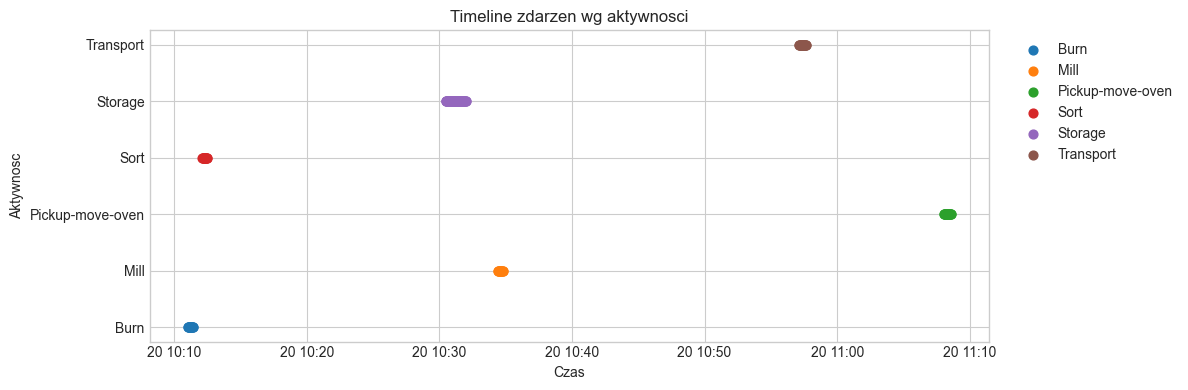

In [ ]:
# Pokazuje sekwencję czasową zdarzeń dla każdej aktywności
# Pozwala zobaczyć przebieg procesów i ewentualne luki czasowe

plt.figure(figsize=(12, 4))
for activity, group in df.sort_values('timestamp').groupby('activity'):
    # Dla każdej aktywności rysujemy punkty na osi czasu
    plt.scatter(group['timestamp'], [activity] * len(group), s=40, label=activity)

plt.title('Timeline zdarzen wg aktywnosci')
plt.xlabel('Czas')
plt.ylabel('Aktywnosc')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Powyższe przedstawienie procesów w czasie, daje pewien zarys opisywanego procesu:
1) W pierwszej kolejności "coś" jest pogrzewane/palone.
2) Następnie po podgrzaniu jest OD RAZU sortowane (filtrowane, przesiewane, oddzielane).
3) Posortowane "coś" jest składowane (lecz nie wiadomo skąd tak wyraźna przerwa czasowa między sortowaniem, a składowaniem - może potrzeba redukcji temperatury?).
4) Po składowaniu "to coś" jest mielone. Po procesie mielenia znów widać przerwę czasową, w której nie mamy informacji co dzieje się z "tym produktem". 
5) Kolejnym krokiem jest transport, który ze względu na krótki czas jego trwania obejmuje pewnie obszar innej części zakładu. 
6) Po przetransportowaniu "produktu", jest ono przejmowane i pogrzewane. 

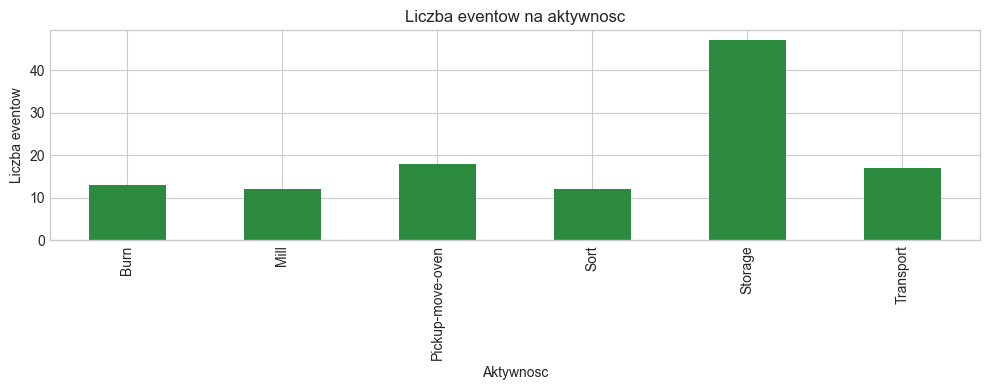

In [16]:

# Liczymy zdarzenia na aktywność i sortujemy po nazwie
freq = df['activity'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
freq.plot(kind='bar', color='#2b8a3e')
plt.title('Liczba eventow na aktywnosc')
plt.xlabel('Aktywnosc')
plt.ylabel('Liczba eventow')
plt.tight_layout()
plt.show()

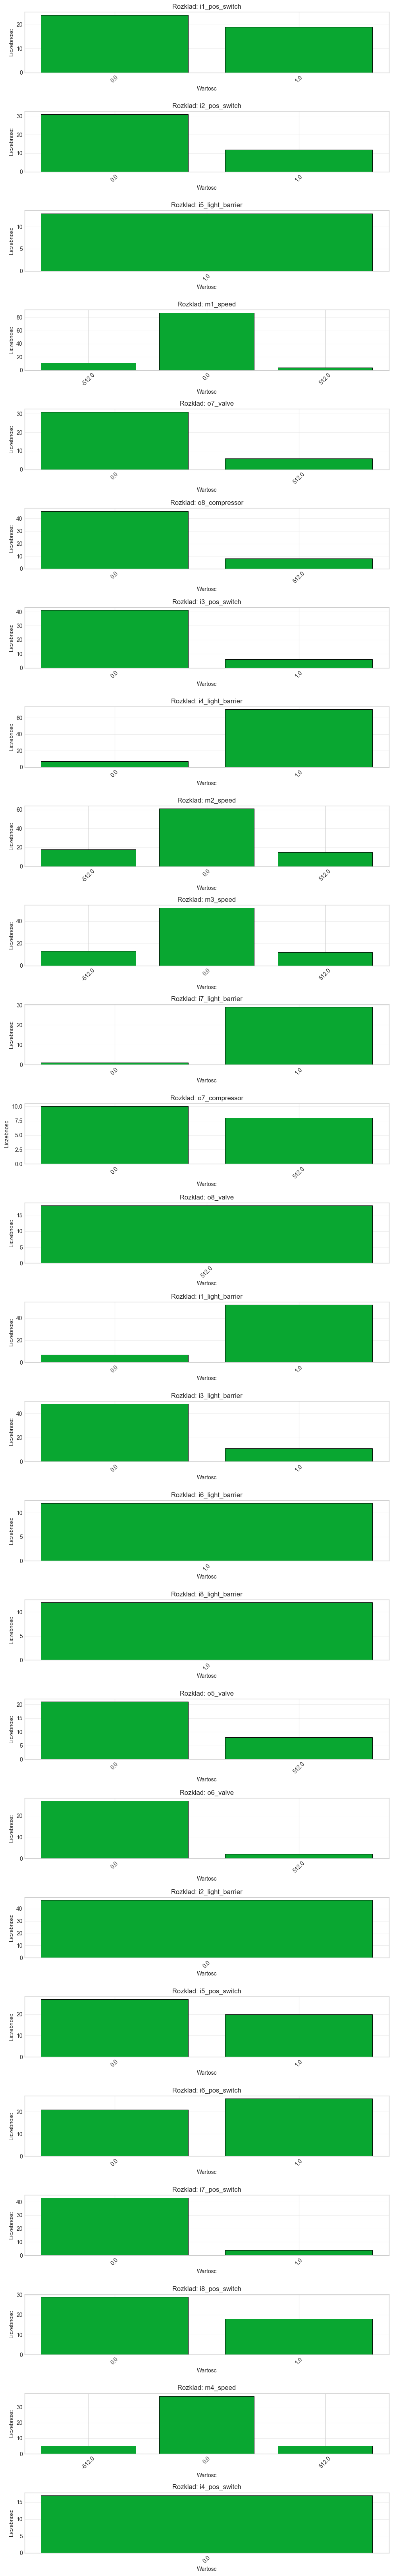

In [ ]:

# Wybieramy tylko kolumny z wartościami numerycznymi
numeric_signals = [c for c in signal_cols if pd.api.types.is_numeric_dtype(df[c])]
top_signals = numeric_signals  # Pokazujemy wszystkie dostępne sygnały

if top_signals:
    # Transformujemy dane do formatu "long" (jeden wiersz = jedna wartość)
    long_signals = df.melt(id_vars=['activity'], value_vars=top_signals, var_name='signal', value_name='value')

    # Tworzymy subplot dla każdego sygnału
    fig, axes = plt.subplots(len(top_signals), 1, figsize=(10, 2.5 * len(top_signals)), sharex=False)
    if len(top_signals) == 1:
        axes = [axes]  # Jeśli jest tylko jeden sygnał, zamień na listę

    for ax, sig in zip(axes, top_signals):
        vals = long_signals.loc[long_signals['signal'] == sig, 'value']
        
        # Inteligentne wybór typu wykresu w zależności od liczby unikalnych wartości
        unique_vals = sorted(vals.dropna().unique())
        num_unique = len(unique_vals)
        
        if num_unique <= 15:
            # Dla dyskretnych wartości (np. 0, 1, ±512): słupki dla każdej wartości
            val_counts = vals.value_counts().sort_index()
            ax.bar(range(len(val_counts)), val_counts.values, color='#09a731', edgecolor='black', linewidth=0.7)
            ax.set_xticks(range(len(val_counts)))
            ax.set_xticklabels([str(v) for v in val_counts.index], rotation=45)
        else:
            # Dla wartości ciągłych: histogram z binami
            ax.hist(vals, bins=20, color="#09a731", edgecolor='black', linewidth=0.7)
        
        ax.set_title(f'Rozklad: {sig}')
        ax.set_xlabel('Wartosc')
        ax.set_ylabel('Liczebnosc')
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Brak numerycznych sygnalow do wizualizacji.')

In [ ]:
# Liczymy czas trwania każdego przypadku (od pierwszego do ostatniego zdarzenia)

case_durations = (
    df.groupby('case_id')['timestamp']
      .agg(start='min', end='max')  # Pierwszy i ostatni timestamp
      .assign(duration_seconds=lambda x: (x['end'] - x['start']).dt.total_seconds())  # Różnica w sekundach
      .reset_index()
)

case_durations

,case_id,start,end,duration_seconds
0,case_Burn_001,2023-03-20 10:11:01+00:00,2023-03-20 10:11:26+00:00,25.0
1,case_Mill_001,2023-03-20 10:34:25+00:00,2023-03-20 10:34:48+00:00,23.0
2,case_Pickup-move-oven_001,2023-03-20 11:08:02+00:00,2023-03-20 11:08:36+00:00,34.0
3,case_Sort_001,2023-03-20 10:12:06+00:00,2023-03-20 10:12:29+00:00,23.0
4,case_Storage_001,2023-03-20 10:30:28+00:00,2023-03-20 10:32:01+00:00,93.0
5,case_Transport_001,2023-03-20 10:57:07+00:00,2023-03-20 10:57:39+00:00,32.0


## Wnioski (Milestone 1)

1. Podzbior zawiera sygnatury 6 aktywnosci (6 procesów), po 1 przypadku (case) na aktywnosc.
2. Dane sa dobrze ustrukturyzowane czasowo (timestamp ISO, brak bledow parsowania).
3. W danych nie ma jawnego `case_id` ani klasycznego `resource` (osoba);
   role zasobu technicznie pelni `station`.
4. Sygaly czujnikow/aktuatorow maja charakter dyskretny (czesto wartosci 0, 1, +/-512).
5. Zbior nadaje sie do: detekcji sekwencji aktywnosci, walidacji reguł CEP i przygotowania logu
   pod dalsze etapy process mining (np. modelowanie procesu i conformance checking).
6. Dane umożliwiają odtworzenie procesu, który opisują